In [6]:
!pip install dataframe_image

In [7]:
import pandas as pd
import numpy as np
import copy as cp
from math import nan
from statistics import mean
from sklearn.model_selection import train_test_split
import dataframe_image as dfi
import matplotlib.pyplot as plt
import seaborn as sns
import math as m

## **DataPreprocess**

The `DataPreprocess` class is used for preprocessing tabular data, especially for discretizing numerical features. It includes the following methods:


- **`discretizeForAll(self, bins, labels, target_col)`**:  
  Discretizes numeric features (columns starting with `'Q'`) into equal-width bins using `pandas.cut()`.  
  - Skips the target column to preserve its original values.  
  - Fills any resulting `NaN` with the most frequent (mode) value of the column.  
  - Removes unnamed columns (e.g., from CSV indices).  
  - Stores the target column in `self.target` and remaining columns in `self.features`.  
  - Saves the final discretized DataFrame to `self.discretizedData`.




In [8]:
class DataPreprocess:
  def __init__(self):
    self.rawData = None
    self.discretizedData = None
    self.target = None
    self.features = None
    self.labes = []
    self.bins = []

  def load(self, filePath):
    self.rawData = pd.read_csv(filePath)


  def discretize_for_all(self, bins: list, labels: list, target_col):
    '''
    Discretize the data with equal width bins:
    bins: list of bin edges of equal width
    labels: list of bin abrity labels
    target_col: target column name

    '''
    self.bins = bins
    self.categories = categories
    dataFrame = self.rawData.copy()
    for column in [col for col in dataFrame.columns if col.startswith('Q')]:
        if column == target_col:
            continue
        dataFrame[column] = pd.cut(dataFrame[column], bins, labels=labels,
                            include_lowest=True, right=True, duplicates='drop')
        dataFrame[column] = dataFrame[column].fillna(dataFrame[column].mode()[0])
    dataFrame = dataFrame.loc[:, ~dataFrame.columns.str.contains('^Unnamed')]
    self.target = dataFrame[target_col]
    self.features = dataFrame.drop([target_col,'#'], axis=1)
    self.discretizedData = dataFrame

  def discretize_for_instance(self, bins: list, labels: list,
                              instance: pd.Series) -> pd.Series:
    '''
    Discretize for one instance (for predict instance purpose)
    '''
    return pd.cut(instance, bins, labels=labels,
                            include_lowest=True, right=True, duplicates='drop')

  def get_discretized_data(self)-> pd.DataFrame:
    return self.discretizedData

  def get_raw_data(self) -> pd.DataFrame:
    return self.rawData

## **NaiveBayesClassifier**

The `NaiveBayesClassifier` class implements a simple Naive Bayes algorithm for classification tasks. It supports Laplace smoothing and works with categorical features. It includes the following methods:


- **`laplace_smothing(self, alpha)`**:  
  Applies Laplace smoothing to feature likelihoods `P(X_i | y)` to handle zero probabilities.  
  Also smoothing class probabilities `P(y)` over total samples.

- **`fit(self, X, y)`**:  
Trains the classifier using the feature matrix `X` and target vector `y`.  
  - Calculates prior probabilities `P(y)` for each class.  
  - Computes conditional probabilities `P(X_i | y)` for each feature given each class.

- **`predict_instance(self, instance)`**:  
  Predicts the class for a single instance using log-probabilities of each class.  
  Returns the class with the highest log-probability.

- **`predict(self, X)`**:  
  Predicts class labels for all instances in the dataset `X`.




In [9]:
class NaiveBayesClassifier:
  def __init__(self):
    self.class_probs = None
    self.features_probs = None
    self.class_counts = None
    self.feature_counts = None
    self.n_features = None
    self.n_samples = None

  def laplace_smothing(self, alpha=1):
      '''
      Laplace smoothing for P(X_i | y) and P(y)
      alpha: Laplace smoothing parameter (default = 1)
      '''
      # --- Smoothed class probabilities: P(y) ---
      m = len(self.class_counts)  # number of classes
      total = sum(self.class_counts.values())  # total samples

      self.class_probs = {}
      for cls in self.class_counts:
          a = (self.class_counts[cls] + alpha)
          b = (total + m * alpha)
          self.class_probs[cls] = a / b

      # --- Smoothed feature probabilities: P(X_i | y) ---
      self.features_probs = {}
      for feature, class_data in self.feature_counts.items():
          smoothed_feature = {}

          #--- Get all possible values of this feature across all classes ---
          feature_values = set()
          for cls_vals in class_data.values():
              feature_values.update(cls_vals.keys())
          r = len(feature_values)

          for cls in class_data:
              smoothed_feature[cls] = {}
              cls_count = self.class_counts[cls]

              for val in feature_values:
                  count = self.feature_counts[feature][cls].get(val, 0)
                  a = count + alpha
                  b = cls_count + alpha * r
                  self.feature_counts[feature][cls][val] = f'{a}/{b}'
                  smoothed_feature[cls][val] = a / b

          self.features_probs[feature] = smoothed_feature

  def fit(self, X: pd.DataFrame, y: pd.Series)-> tuple[str, int]:
    '''
    Training the model with:
    X: features of  traning data -> Q1,...Qn
    y: target of training data -> Rank
    '''
    self.n_samples, self.n_features = X.shape
    # --- Caculate P(y) ---
    self.class_counts = y.value_counts(normalize=False).to_dict()

    # --- Calculate each P(X_i | y) ---
    self.feature_counts = {}
    for feature in X.columns:
      self.feature_counts[feature] = {}
      for class_val in self.class_counts:
        counts = X[y == class_val][feature].value_counts(normalize=False).to_dict()
        self.feature_counts[feature][class_val] = counts

    #--- Smothing data ---
    self.laplace_smothing()

  def predict_instance(self, instance: pd.Series) -> tuple([str, int]):
    '''
    Predict the class value P/F using sum of log-probabilities
    instance: of input data sample (X) [Q1,...Qn]
    '''
    log_probs = {}
    for class_val in self.class_probs:
      log_prob = np.log(self.class_probs[class_val])
      for feature in instance.index:
        feature_val = instance[feature]

        # --- Skiping missing feature_val continue ---
        if pd.isnull(feature_val):
          continue

        # --- If the feature value exists in training data ---
        if feature_val in self.features_probs[feature][class_val]:
          log_prob += np.log(self.features_probs[feature][class_val][feature_val])
      log_probs[class_val] = log_prob

    # --- Return class with highest log-probability ---
    probs = {cls: np.exp(logp) for cls, logp in log_probs.items()}
    predict_class = max(probs, key=probs.get)

    # --- Normalize the result probability ---
    total = sum(probs.values())
    normalized_probs = {cls: (prob / total)*100 for cls, prob in probs.items()}
    confidence = max(normalized_probs.values())
    return predict_class, confidence

  def predict(self, X):
    '''
    Predict the class for all dataset
    return the Series of value of class P or F
    '''
    predictions = X.apply(self.predict_instance, axis=1)
    return predictions

  def show_predict(self, dp: DataPreprocess, instance: pd.Series):
    resultDF = pd.DataFrame()
    resultDF['Non-discretized'] = instance
    instance = dp.discretize_for_instance(dp.bins, dp.categories, instance)
    resultDF['Discretized'] = instance
    instanceResult = self.predict_instance(instance)
    print(resultDF)
    predictClass = instanceResult[0]
    confidence = instanceResult[1]
    print(f'Predicted Class: {predictClass}, Confidence: {confidence}')

  def get_likelyhood_table(self, categories: list) -> pd.DataFrame:
    '''
    Show the Likelyhood probability table P(X_i | y)
    '''
    temp = self.feature_counts
    for feature in temp:
      for cls in temp[feature]:
        temp[feature][cls] = {k: temp[feature][cls][k] for k in categories
                              if k in temp[feature][cls]}
    df = pd.DataFrame()
    attribute = []
    P_value = []
    F_value = []
    for feature,data in self.feature_counts.items():
        for label, prob in data.items():
          if label == 'P':
            for val, p in prob.items():
              attribute.append(f'{feature}={val}')
              P_value.append(p)
          if label == 'F':
            for val, p in prob.items():
              F_value.append(p)

    df['Attribute'] = attribute
    df['Rank = P'] = P_value
    df['Rank = F'] = F_value
    return df

  def get_prior_table(self, categories: list) -> pd.DataFrame:
      '''
      Show the the prior table P(y)
      '''
      df = pd.DataFrame()
      m = len(self.class_counts)
      total = sum(self.class_counts.values())

      # Laplace smoothed probabilities
      smoothed_probs = {}
      for cls in self.class_counts:
          a = self.class_counts[cls] + 1
          b = total + m
          smoothed_probs[cls] = (a, b)

      df['Rank = P'] = [f"{smoothed_probs['P'][0]} / {smoothed_probs['P'][1]}"]
      df['Rank = F'] = [f"{smoothed_probs['F'][0]} / {smoothed_probs['F'][1]}"]

      return df

  def visualize_the_likelihood(self, dp, likelihood):
      if likelihood is None or likelihood.empty:
          print("No likelihood table to visualize.")
          return

      categories = dp.categories
      n_cate = len(categories)
      cols = 2
      rows = m.ceil(n_cate / cols)

      fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows),
                               constrained_layout=True)
      if n_cate == 1:
          axes = [[axes]]
      elif rows == 1:
          axes = [axes]
      elif cols == 1:
          axes = [[ax] for ax in axes]

      melted_df = likelihood.melt(id_vars='Attribute',
                                  var_name='Class', value_name='Probability')

      def to_float(val):
          if isinstance(val, str) and '/' in val:
              try:
                  num, denom = val.split('/')
                  return float(num) / float(denom)
              except:
                  return None
          return float(val)

      melted_df['Probability'] = melted_df['Probability'].apply(to_float)

      for idx, category in enumerate(categories):
          row, col = divmod(idx, cols)
          ax = axes[row][col] if rows > 1 else axes[0][col]

          cate_df = melted_df[melted_df['Attribute'].str.endswith(f'={category}')]

          if cate_df.empty:
              ax.set_title(f"Category = {category} (no data)")
              ax.axis('off')
              continue

          sns.barplot(data=cate_df, x='Attribute', y='Probability',
                      hue='Class', ax=ax)
          ax.set_title(f"Category = {category}")
          labels = [label.get_text() for label in ax.get_xticklabels()]
          ax.set_xticks(range(len(labels)))
          ax.set_xticklabels(labels, rotation=45, ha='right')

      total_plots = rows * cols
      for i in range(n_cate, total_plots):
          row, col = divmod(i, cols)
          ax = axes[row][col] if rows > 1 else axes[0][col]
          ax.axis('off')

      plt.suptitle('Likelihood Table by Category', fontsize=16)
      plt.show()

  def evaluation_for_all_dataset(self, features, labels, visualize=False):
      """
      Evaluate the accuracy of the model on the entire dataset
      and optionally visualize results.

      features: DataFrame containing the features (X)
      labels: List or Series containing the true labels (y)
      visualize: Bool - if True, show a pie chart of correct
      vs incorrect predictions
      """
      if features is None or labels is None or features.empty:
          print("Invalid data or data not yet processed.")
          return

      print("\n--- Evaluating Accuracy on the entire dataset ---")

      # Predict labels
      msg = "Number of predicted labels does not match number of actual labels"
      predictions_with_confidence = self.predict(features)
      predicted_labels = [pred[0] for pred in predictions_with_confidence]

      if len(predicted_labels) != len(labels):
          print(msg)
          return

      # Count correct predictions
      correct = sum(p == t for p, t in zip(predicted_labels, labels))
      incorrect = len(labels) - correct
      accuracy = (correct / len(labels)) * 100
      error_rate = 100 - accuracy

      print(f"Number of correctly classified instances: {correct}/{len(labels)}")
      print(f"Accuracy of the Naive Bayes Classifier on the dataset: {accuracy:.2f}%")

      # Show pie chart if visualize is True
      if visualize:
        categories = ['Correct', 'Incorrect']
        counts = [correct, incorrect]
        colors = ['green', 'red']

        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(categories, counts, color=colors)

        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12, color='black')

        ax.set_ylim(0, len(labels))
        ax.set_title('Prediction Results for Entire Dataset')
        ax.set_ylabel('Number of Instances')

        plt.show()

## **Testing and Evaluating**

In [10]:
#Prepare the parameter and data for model
dp = DataPreprocess()
dp.load('task4_data.csv')
bins = [0, 2.6, 5.1, 7.6, 10]
categories = ['VL', 'L', 'M', 'H'] #Very low, Low, Medium, High
dp.discretize_for_all(bins, categories, target_col = 'Rank')
discretized_df = dp.get_discretized_data()

#Initializing the model and evaluating model
myModel = NaiveBayesClassifier()
myModel.fit(dp.features, dp.target)

##**Likelihood And Prior Probability**##

In [11]:
print("Likelihood Probability Table:")
likelihoodTable = myModel.get_likelyhood_table(categories)
likelihoodTable

Likelihood Probability Table:


,Attribute,Rank = P,Rank = F
0,Q1=VL,96/181,71/94
1,Q1=L,74/181,19/94
2,Q1=M,10/181,3/94
3,Q1=H,1/181,1/94
4,Q2=VL,26/181,31/94
5,Q2=L,23/181,11/94
6,Q2=M,55/181,25/94
7,Q2=H,77/181,27/94
8,Q3=VL,27/181,30/94
9,Q3=L,69/181,41/94


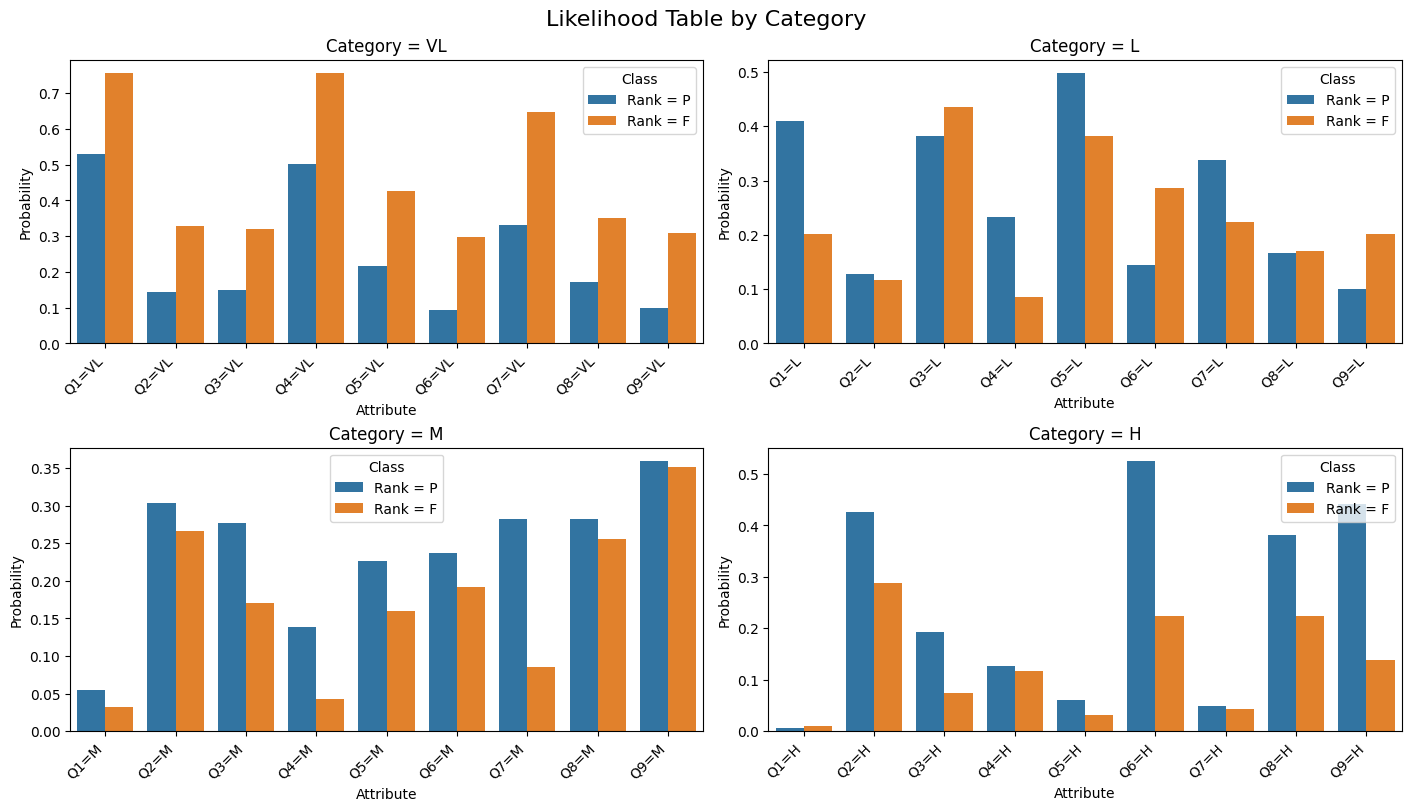

In [12]:
myModel.visualize_the_likelihood(dp, likelihoodTable)

In [13]:
print("Prior Probability Table:")
myModel.get_prior_table(categories)

Prior Probability Table:


,Rank = P,Rank = F
0,178 / 269,91 / 269


##**Test for 4 random input instances**##

In [14]:
#Test for a single instance
instance1 = pd.Series({
    'Q1': 0,
    'Q2': 0,
    'Q3': 0,
    'Q4': 0,
    'Q5': 2,
    'Q6': 6,
    'Q7': 0,
    'Q8': 6.4,
    'Q9': 6.4,
})
print("Predict for instance 1:")
myModel.show_predict(dp, instance1)
print()

instance2 = pd.Series({
    'Q1': 1,
    'Q2': 1,
    'Q3': 4,
    'Q4': 5,
    'Q5': 6,
    'Q6': 7,
    'Q7': 9,
    'Q8': 7,
    'Q9': 8,
})
print("Predict for instance 2:")
myModel.show_predict(dp, instance2)
print()

instance3 = pd.Series({
    'Q1': 2,
    'Q2': 9,
    'Q3': 7,
    'Q4': 8,
    'Q5': 6,
    'Q6': 1,
    'Q7': 5,
    'Q8': 6.4,
    'Q9': 9,
})
print("Predict for instance 3:")
myModel.show_predict(dp, instance3)
print()

instance3 = pd.Series({
    'Q1': 5,
    'Q2': 9,
    'Q3': 5,
    'Q4': 8,
    'Q5': 6,
    'Q6': 5,
    'Q7': 5,
    'Q8': 5,
    'Q9': 9,
})
print("Predict for instance 4:")
myModel.show_predict(dp, instance3)

Predict for instance 1:
    Non-discretized Discretized
Q1              0.0          VL
Q2              0.0          VL
Q3              0.0          VL
Q4              0.0          VL
Q5              2.0          VL
Q6              6.0           M
Q7              0.0          VL
Q8              6.4           M
Q9              6.4           M
Predicted Class: F, Confidence: 93.6829665396088

Predict for instance 2:
    Non-discretized Discretized
Q1                1          VL
Q2                1          VL
Q3                4           L
Q4                5           L
Q5                6           M
Q6                7           M
Q7                9           H
Q8                7           M
Q9                8           H
Predicted Class: P, Confidence: 91.18771557129841

Predict for instance 3:
    Non-discretized Discretized
Q1              2.0          VL
Q2              9.0           H
Q3              7.0           M
Q4              8.0           H
Q5              6.0        

##**Evaluation Accuracy on the entire dataset**##


--- Evaluating Accuracy on the entire dataset ---
Number of correctly classified instances: 204/267
Accuracy of the Naive Bayes Classifier on the dataset: 76.40%


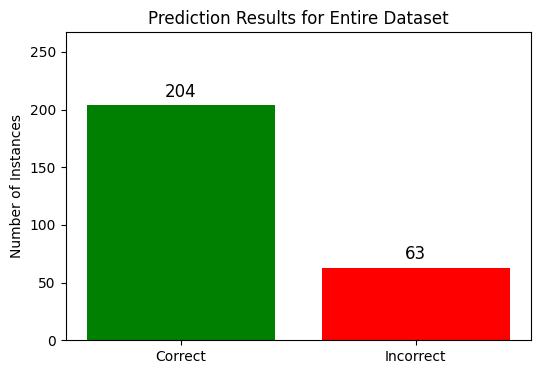

In [15]:
myModel.evaluation_for_all_dataset(dp.features, dp.target, visualize=True)